# Assignment 1 - Data and Probability Foundations

Daniel Munteanu, Josip Brljevic, Luca Mouawad, Zygmunt Tadeusz Kwasniewicz

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Part 1

In [2]:
df = pd.read_csv("assignment01_digital_services.csv")

freq = pd.DataFrame({
    "count": df["alert_type"].value_counts(),
    "percentage": df["alert_type"].value_counts(normalize=True) * 100
})

print(freq.round(2))


                     count  percentage
alert_type                            
none                   104       72.22
authentication          25       17.36
rate_limit               9        6.25
injection_signature      6        4.17


In [3]:
latency = df["latency_ms"]

summary = pd.Series({
    "n": latency.size,
    "mean": latency.mean(),
    "median": latency.median(),
    "std_sample": latency.std(),
    "min": latency.min(),
    "q1": latency.quantile(0.25),
    "q3": latency.quantile(0.75),
    "max": latency.max()
})

summary["iqr"] = summary["q3"] - summary["q1"]

print(summary.round(2))


n             144.00
mean          110.11
median        106.93
std_sample     23.10
min            75.21
q1             95.84
q3            116.88
max           223.80
iqr            21.04
dtype: float64


     service   n    mean  median  std_sample    min      q1      q3     max  \
0     orders  50  122.20  114.52       24.81  98.53  109.84  124.15  223.80   
1  telemetry  45  111.97  106.92       19.38  86.78   97.95  116.83  177.87   
2   identity  49   96.07   93.72       16.12  75.21   85.39  105.10  154.27   

     iqr  
0  14.31  
1  18.88  
2  19.71  


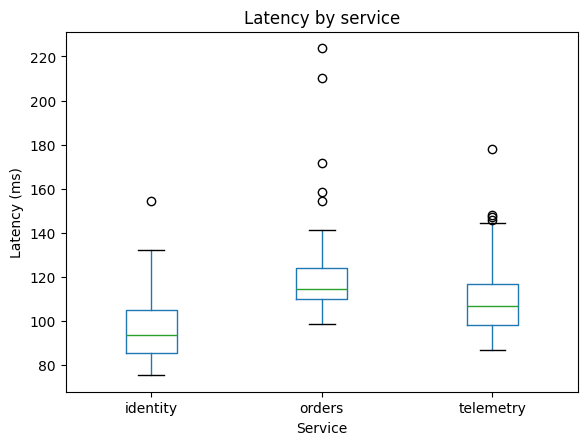

In [4]:
summaries = []
for x in df["service"].unique():
    service_latency = df.loc[df["service"] == x, "latency_ms"]
    summary = pd.Series({
        "service": x,
        "n": service_latency.size,
        "mean": service_latency.mean(),
        "median": service_latency.median(),
        "std_sample": service_latency.std(),
        "min": service_latency.min(),
        "q1": service_latency.quantile(0.25),
        "q3": service_latency.quantile(0.75),
        "max": service_latency.max(),
        "iqr": service_latency.quantile(0.75) - service_latency.quantile(0.25)
    })
    summaries.append(summary)
    

print(pd.DataFrame(summaries).round(2))

df.boxplot(column="latency_ms", by="service", grid=False)
plt.title("Latency by service")
plt.suptitle("")
plt.xlabel("Service")
plt.ylabel("Latency (ms)")
plt.show()


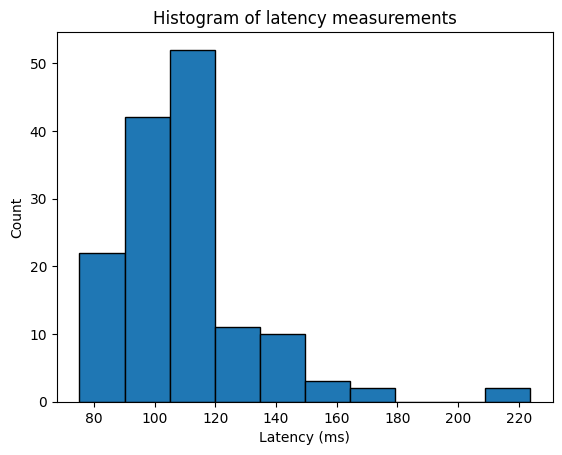

In [5]:
plt.hist(df["latency_ms"], bins=10, edgecolor="black")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.title("Histogram of latency measurements")
plt.show()


In [6]:
outlier_rows = []

for service, group in df.groupby("service"):
    q1 = group["latency_ms"].quantile(0.25)
    q3 = group["latency_ms"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    service_outliers = group[
        (group["latency_ms"] < lower_bound) |
        (group["latency_ms"] > upper_bound)
    ].copy()

    service_outliers["lower_bound"] = lower_bound
    service_outliers["upper_bound"] = upper_bound
    outlier_rows.append(service_outliers)

outliers = pd.concat(outlier_rows)

print(outliers[[
    "observation_id", "service", "latency_ms", "alert_type", "lower_bound", "upper_bound"
]].round(2))


     observation_id    service  latency_ms           alert_type  lower_bound  \
131             132   identity      154.27                 none        55.83   
18               19     orders      210.10                 none        88.37   
59               60     orders      171.59           rate_limit        88.37   
65               66     orders      158.59                 none        88.37   
86               87     orders      154.32       authentication        88.37   
87               88     orders      223.80  injection_signature        88.37   
32               33  telemetry      147.26       authentication        69.63   
38               39  telemetry      145.52                 none        69.63   
119             120  telemetry      147.79                 none        69.63   
132             133  telemetry      177.87                 none        69.63   

     upper_bound  
131       134.66  
18        145.61  
59        145.61  
65        145.61  
86        145.61  
87   

# Comments 

a) obervational unit: would be one observed request/service call, not just the latency itself. The population would be the wider set of service calls that these observations are supposed to represent. latency_ms is quantative, service and alert_type are categorical, and observation_id is just an identifier.

b) the latency summary shows centre and spread. The mean and median show the typical latency, while the sample standard deviation, quartiles and IQR show how much the values vary. The standard deviation is the sample standard deviation, so it uses n - 1.

c) histogram shows the count of delays (y axis) by the duration of the delay (x axis). Shape shows majority of delays in the range of 80-120 with a few exceptions in the 120+ range. There are 10 bins, each repesenting a range of latency values. The box plots show the median, the IQR being the box itself, which shows the range between Q1 and Q3, so the centre 50%, whiskers which show the lowest and highest values inside the Q1 - 1.5IQR and Q3 + 1.5IQR fences. The empty dots display outliars, so data points outside those fences.

d) the outliars were calculated within each service, because each service has its own typical latency and spread. They are most likely not automatically errors, as it is entirely possible that the latency was increased due to outside influence, congestion, security checks, etc., which is an entirely valid observation and not necessarily an incorrect recording.

e) orders has the highest typical latency based on both mean and median, telemetry is in the middle, and identity has the lowest typical latency. orders also has the largest sample standard deviation, so it has the largest overall spread. For all services the mean is higher than the median, which suggests right skewness because some high latency values pull the mean upward. These are only descriptive differences in this sample, so we cannot say that one service is generally slower in the whole population, or that the service itself causes the differences, without later inferential methods.


# Part 2

In [7]:
df2 = pd.read_csv("assignment01_smart_building.csv")

summary = df2.groupby("zone")[["indoor_temp_c", "energy_kwh"]].agg(["count", "mean", "median", "std"])

print(summary)


      indoor_temp_c                              energy_kwh                    \
              count       mean  median       std      count       mean median   
zone                                                                            
north            48  21.276458  21.240  0.614563         48  39.446458  39.84   
south            48  22.267083  22.285  0.548208         48  37.331042  37.08   

                 
            std  
zone             
north  3.975399  
south  4.151442  


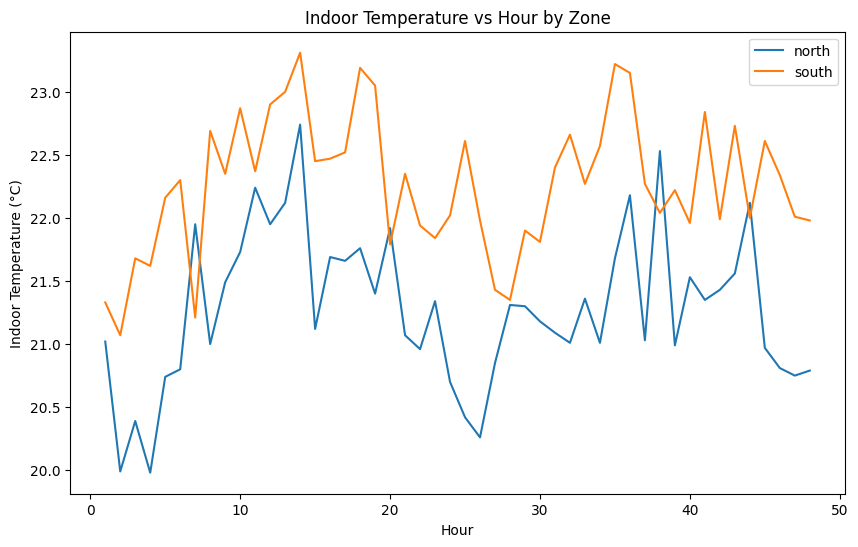

In [8]:
plt.figure(figsize=(10, 6))
for zone in df2["zone"].unique():
    zone_data = df2[df2["zone"] == zone]
    plt.plot(zone_data["hour"], zone_data["indoor_temp_c"], label=zone)
plt.title("Indoor Temperature vs Hour by Zone")
plt.xlabel("Hour")
plt.ylabel("Indoor Temperature (°C)")
plt.legend()
plt.show()

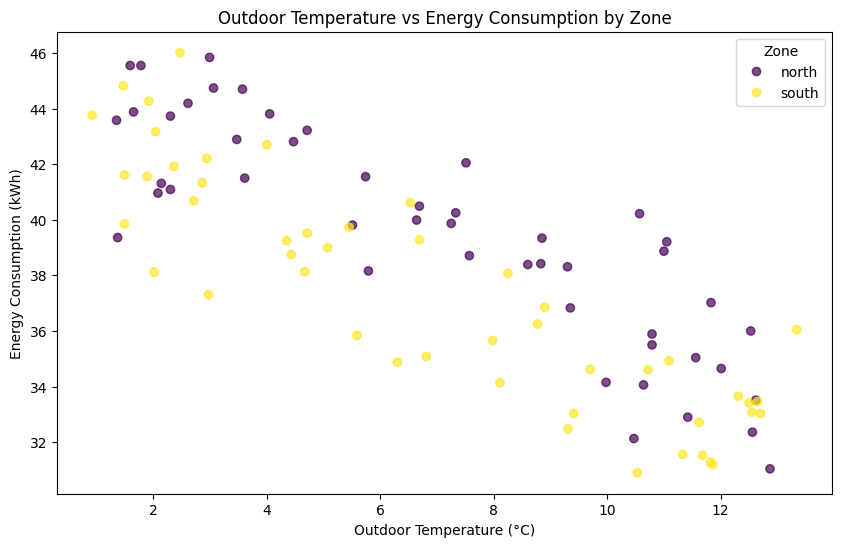

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df2["outdoor_temp_c"], df2["energy_kwh"],
                        c=df2["zone"].astype('category').cat.codes, cmap='viridis', alpha=0.7)
plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Energy Consumption (kWh)")
handles, labels = scatter.legend_elements()
plt.legend(handles, df2["zone"].unique(), title="Zone")
plt.title("Outdoor Temperature vs Energy Consumption by Zone")
plt.show()

**Temperature Stability** -- The north temperatue is more volatile having sharp spikes, suggesting is more sensitive to outdoor factors like sun exposure, wind, etc.

**Temperature Differences** -- We can see that the indoor temperature is usually higher in the south than in the north.

**Energy vs Temperature** -- Another observation is that as outdoor temperature rises, energy use drops. Basically colder outdoor conditions require more energy to maintain indoor comfort.

# Comments
a) observational unit is a measurment for one zone at one hour, containing temperature inside, outside and the energy used

b) Pattern shows the expected fluctiuations within a day, with colder periods every 24 hours (nights) and warmer ones also every 24 hours (days). South is usually at least 1C warmer than the north. X axis represents the hour of the experiment, while the y axis shows the temperature in centigrade

c) Direction shows a negative association between the outdoor temperature and energy consumption. 

d) See python code above

# Part 3

In [10]:
n = 100_000

P_M = 0.006
P_A_given_M = 0.97
P_A_given_not_M = 0.015

n_M = n * P_M
n_not_M = n - n_M

n_M_A = n_M * P_A_given_M
n_M_not_A = n_M - n_M_A

n_not_M_A = n_not_M * P_A_given_not_M
n_not_M_not_A = n_not_M - n_not_M_A

table = pd.DataFrame(
    {
        "Alert (A)": [n_M_A, n_not_M_A],
        "No Alert (A^c)": [n_M_not_A, n_not_M_not_A],
    },
    index=["Malicious (M)", "Not malicious (M^c)"]
).astype(int)

table["Row total"] = table.sum(axis=1)
table.loc["Column total"] = table.sum(axis=0)

print(table)

P_M_and_A = P_A_given_M * P_M

P_A = P_A_given_M * P_M + P_A_given_not_M * (1 - P_M)

P_M_or_A = P_M + P_A - P_M_and_A

P_M_given_A = P_M_and_A / P_A

P_not_M_given_A = 1 - P_M_given_A

print(f"P(M and A) = {P_M_and_A}")
print(f"P(A) = {P_A}")
print(f"P(M or A) = {P_M_or_A}")
print(f"P(M given A) = {P_M_given_A}")
print(f"P(not M given A) = {P_not_M_given_A}")

                     Alert (A)  No Alert (A^c)  Row total
Malicious (M)              582              18        600
Not malicious (M^c)       1491           97909      99400
Column total              2073           97927     100000
P(M and A) = 0.00582
P(A) = 0.02073
P(M or A) = 0.020909999999999998
P(M given A) = 0.28075253256150506
P(not M given A) = 0.719247467438495


**Verification with the table**

For 100,000 attempts, the model gives 600 malicious attempts and 99,400 legitimate attempts.

| Attempt type | Alert (A) | No alert (A^c) | Total |
|---|---:|---:|---:|
| Malicious (M) | 582 | 18 | 600 |
| Not malicious (M^c) | 1491 | 97909 | 99400 |
| Total | 2073 | 97927 | 100000 |

P(M and A) = 582 / 100000 = 0.00582

P(A) = 2073 / 100000 = 0.02073

P(M or A) = P(M) + P(A) - P(M and A) = 0.006 + 0.02073 - 0.00582 = 0.02091

P(M | A) = 582 / 2073 = 0.28075

P(not M | A) = 1491 / 2073 = 0.71925


In [11]:
print(582/100000)
print(2073/100000)
print(582/2073)

0.00582
0.02073
0.28075253256150506


P(A|M) = 0.97 - it describes the detector's capability of catching attacks. So out of malicious attempts, 97% are expected to alert.

P(M|A) = 0.28 - is basically what a security analyst would look for because it represents how likely there is a real attack given an alert.

These two are not the same because the denominator is different. P(A|M) looks only at malicious attempts, while P(M|A) looks only at alerted attempts.

M and A are not independent because P(A|M) is different from P(A). Here P(A|M) = 0.97, while P(A) = 0.02073.

M and A are not mutually excluse since P(M and A) = 0.00582, not 0. This means that an attempt can be both malicious and alerted.


In [12]:
n = 100_000

P_M = 0.006
P_A_given_M = 0.97
P_A_given_not_M = 0.005

n_M = n * P_M
n_not_M = n - n_M

n_M_A = n_M * P_A_given_M
n_M_not_A = n_M - n_M_A

n_not_M_A = n_not_M * P_A_given_not_M
n_not_M_not_A = n_not_M - n_not_M_A

table = pd.DataFrame(
    {
        "Alert (A)": [n_M_A, n_not_M_A],
        "No Alert (A^c)": [n_M_not_A, n_not_M_not_A],
    },
    index=["Malicious (M)", "Not malicious (M^c)"]
).astype(int)

table["Row total"] = table.sum(axis=1)
table.loc["Column total"] = table.sum(axis=0)

print(table)

P_M_and_A = P_A_given_M * P_M

P_A = P_A_given_M * P_M + P_A_given_not_M * (1 - P_M)

P_M_or_A = P_M + P_A - P_M_and_A

P_M_given_A = P_M_and_A / P_A

P_not_M_given_A = 1 - P_M_given_A

print(f"P(M and A) = {P_M_and_A}")
print(f"P(A) = {P_A}")
print(f"P(M or A) = {P_M_or_A}")
print(f"P(M given A) = {P_M_given_A}")
print(f"P(not M given A) = {P_not_M_given_A}")

                     Alert (A)  No Alert (A^c)  Row total
Malicious (M)              582              18        600
Not malicious (M^c)        497           98903      99400
Column total              1079           98921     100000
P(M and A) = 0.00582
P(A) = 0.010790000000000001
P(M or A) = 0.01097
P(M given A) = 0.5393883225208526
P(not M given A) = 0.46061167747914744


# Comments 

# a) 
The 4 basic outcomes are visible in the table above, those being:
        
        M and A - A malicious attempt causes an alert
        M and A^c - A malicious attempt does not cause an alert
        M^c and A - A legitmate authentication causes an alert
        M^c and A^c - A legitmate authentication does not cause an alert

they are exclusive and exhaustive since these are binary classification (yes/no) and with 2 classifiers that gives us 2^2 so 4. Since all 4 possibilities are listed there is no possibility for there being a 5th one

# b) 
see python code above

# c) 
1. P(M and A) = P(M) * P(A|M) = 0.006 * 0.97 = 0.00582
2. P(A) = P(A|M) * P(M) + P(A|M^c) * P(M^c) = 0.97 * 0.006 + 0.015 * 0.994 = 0.02073 (law of total probability)
3. P(A and M) = P(A) + P(M) - P(A or M)  =>  P(A or M) = P(A) + P(M) - P(A and M) = 0.02073 + 0.006 - 0.00582 = 0.02091
4. P(M|A) = (P(M) * P(A|M)) / P(A) = 0.006 * 0.97 / 0.02073 = ~~ 0.280752 (Bayes' theorem)
5. P(M^c|A) = 1 - P(M|A) = 1 - 0.280752 = ~~ 0.719248

# c2)
## Cleaned up by AI

1. 

   $$
   P(M\cap A)=P(M)P(A\mid M)
   =0.006(0.97)
   =\boxed{0.00582}
   $$

2. **Total probability:**

   $$
   P(A)=P(A\mid M)P(M)+P(A\mid M^c)P(M^c)
   $$

   $$
   =0.97(0.006)+0.015(0.994)
   =\boxed{0.02073}
   $$

3. 

   $$
   P(A\cup M)=P(A)+P(M)-P(A\cap M)
   $$

   $$
   =0.02073+0.006-0.00582
   =\boxed{0.02091}
   $$

4. **Bayes' theorem:**

   $$
   P(M\mid A)=\frac{P(M)P(A\mid M)}{P(A)}
   =\frac{0.006(0.97)}{0.02073}
   \approx\boxed{0.280752}
   $$

5. 

   $$
   P(M^c\mid A)=1-P(M\mid A)
   \approx\boxed{0.719248}
   $$


# d) 
see python code above

# e) 
With the improved system, P(A | M^c) changes from 0.015 to 0.005.

P(A) = 0.97 * 0.006 + 0.005 * 0.994 = 0.01079

P(M | A) = 0.00582 / 0.01079 = 0.53939

P2(M | A) > P1(M | A). This means that with the improved system an alert means there is above a 50% chance of there being an actual threat, compared to the original systems 28%. The false-positive rate matters because legitimate attempts are much more common than malicious attempts, so even a small false-positive rate can create many false alerts.


# Part 4

The main AI use was the autocomplete but frankly speaking, it was helpful just for the syntax of creating the plots and also writing the formulas for part 3. Tutorials from the website from each lesson were used, especially the code snippets so almost no AI was used due to the low difficulty of the tasks.

Edit: 

a) chatGPT

b) AI was used as a reality check in the pandas.DataFrame.loc usage. Also to make markdown prettier

c) changed df[df["service"] == x,"latency_ms"].mean() → df.loc[df["service"] == x,"latency_ms"].mean(). For example see 3.c)

d) checked that code runs as expected. Checked that markdown looks prettier

# Overall conclusion
## Digital services
Case of understanding latency, which in and of itself is largely prone to random increases. This unpredictibility makes it not obvious whether outliers should be ignored or removed. In this case it has been deemed all of the outliers are within acceptable bounds. Limitation likely due to insufficient data, we do not know when or where from did the calls originate so we cannot say much more than "for some reason orders service is the slowest"
## Smart building measurements
Observations of energy usage and indoor / outdoor temperatures. Found obvious association between outdoor temperature and energy usage. This is expected as heating generally requires more energy during colder periods. Confirmed measurements make sense as they follow the fact that nights are colder than days. Limitation is again insufficient data we cannot follow larger trends, especially as the whole data set is across a 50 hour span (very low)
## Cybersecurity alert system
Theoretical case of a system for detecting malicious authentication attempts. Again reminded of the weirdness that is Bayes' theorem. Limitation is that we only calculate what is the P(M|A). That does not change much as every alert should be investigated regardless 
